# **1. Perkenalan Dataset**


Dataset: Telco Customer Churn dari Kaggle (IBM Sample Dataset).
Sumber: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
Jumlah baris: 7043 | Jumlah kolom: 21
Target: Churn (Yes/No) — klasifikasi biner customer churn pada layanan telekomunikasi.
Konteks bisnis: memprediksi pelanggan yang berpotensi berhenti berlangganan
agar tim retention bisa melakukan intervensi.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
import warnings
warnings.filterwarnings('ignore')

print("Library imported successfully")

Library imported successfully


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
import zipfile
import os

# Unzip the archive.zip file
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Check for the correct CSV file name after extraction
# The common filename for this dataset is 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
# If this is still not found, you might need to inspect the contents of the zip file
# or the /content/ directory to find the actual filename.
csv_file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(csv_file_path)
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
# Info dasar
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Statistik deskriptif
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Cek missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal duplicates: {df.duplicated().sum()}")

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total duplicates: 0


In [ ]:
# TotalCharges sebenarnya string — convert ke numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing TotalCharges setelah konversi: {df['TotalCharges'].isnull().sum()}")

Missing TotalCharges setelah konversi: 11


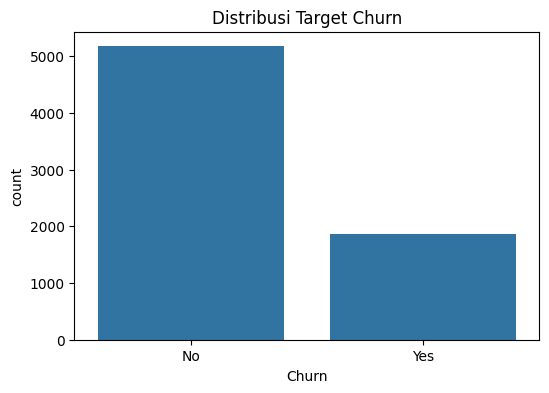

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [ ]:
# Distribusi target
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Distribusi Target Churn')
plt.show()
print(df['Churn'].value_counts(normalize=True))

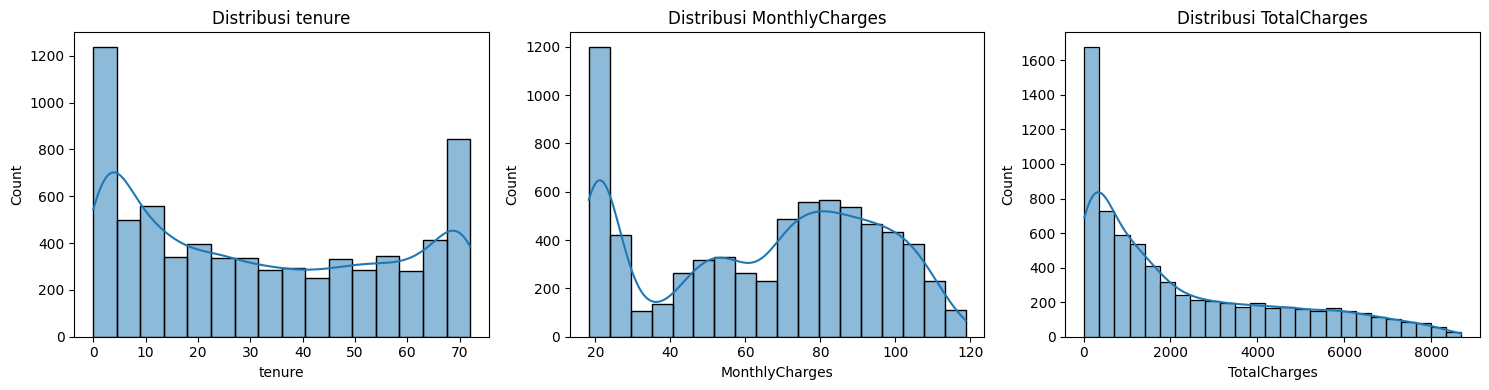

In [ ]:
# Distribusi numerik
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

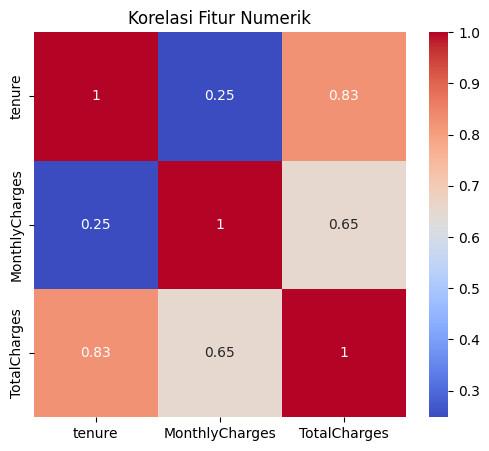

In [ ]:
# Korelasi numerik
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# 1. Drop customerID (tidak informatif)
df_clean = df.drop(columns=['customerID'])

# 2. Handle missing TotalCharges (isi dengan median)
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

# 3. Drop duplikat
df_clean = df_clean.drop_duplicates()

# 4. Encoding target
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# 5. Pisahkan kategorikal dan numerik
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print(f"Kategorikal: {cat_cols}")
print(f"Numerik: {num_cols}")

Kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerik: ['tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
# 6. One-hot encoding kategorikal
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# 7. Pisah X dan y
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# 8. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 9. Scaling numerik
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (5616, 30), X_test: (1405, 30)


In [ ]:
# 10. Simpan ke folder preprocessing
os.makedirs('telco_preprocessing', exist_ok=True)
X_train.to_csv('telco_preprocessing/X_train.csv', index=False)
X_test.to_csv('telco_preprocessing/X_test.csv', index=False)
y_train.to_csv('telco_preprocessing/y_train.csv', index=False)
y_test.to_csv('telco_preprocessing/y_test.csv', index=False)

# Gabungan untuk kemudahan training
train_combined = X_train.copy()
train_combined['Churn'] = y_train.values
train_combined.to_csv('telco_preprocessing/train_processed.csv', index=False)

test_combined = X_test.copy()
test_combined['Churn'] = y_test.values
test_combined.to_csv('telco_preprocessing/test_processed.csv', index=False)

print("✅ Preprocessed data saved to telco_preprocessing/")

✅ Preprocessed data saved to telco_preprocessing/
